<a href="https://colab.research.google.com/github/bsheese/cs377/blob/main/17_regression_crossval/17_1_SLR/17_1_6_SLR_GeneralizationTest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Simple Linear Regression: The Generalization Test (Train/Test Split)

Author: Brad Sheese

---

## What This Notebook Is About

Look at what we've done in this module so far:

- **17_1_1** — fit the line with scikit-learn and statsmodels.
- **17_1_2** — asked whether the slope is statistically real.
- **17_1_3** — checked whether the LINE assumptions behind the summary table hold.
- **17_1_4** — hunted for single bad rows dragging the line around.
- **17_1_5** — transformed variables to fix curved relationships.

Every one of those notebooks is about understanding **how well the line we just fit describes the data we fit it on**. That's useful — but it isn't the reason we fit models in the first place.

The whole point of a regression model is to make predictions on **data we haven't seen yet**. A real-estate company doesn't fit a price model to *re-predict* houses that have already sold. They fit it so they can predict houses that are *about to* sell. A hospital doesn't build a risk model to re-diagnose patients whose outcomes are already known. They build it to score patients walking in the door tomorrow.

This notebook is about the one question that separates "I fit a model" from "I fit a *useful* model":

> **Does my model work on data it has never seen?**

The answer to that question is the most important number in applied machine learning, and getting it requires a small but non-negotiable discipline: **never evaluate a model on the same data you fit it on**. That discipline has a name — the **train/test split** — and it is the gateway to every technique you'll meet in the rest of this course.

## Setup

We'll use the clean Ames Housing data one last time — `area` predicting `price` (in thousands), same setup as Notebook 17_0_5. The new imports come from **scikit-learn**, the library of choice for everything that happens after the "is this slope significant" question.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import io
import urllib.request

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.metrics import r2_score

sns.set_style('whitegrid')
rng = np.random.default_rng(seed=42)

# Ames Housing — same loader as 17_0_5.
url = 'https://www.openintro.org/data/csv/ames.csv'
req = urllib.request.Request(url,
    headers={'User-Agent': 'Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/537.36',
             'Accept': 'text/csv,*/*'})
with urllib.request.urlopen(req) as resp:
    ames = pd.read_csv(io.BytesIO(resp.read()))

X = ames[['area']].to_numpy()              # 2D, because sklearn demands it (see 17_1_1)
y = ames['price'].to_numpy() / 1000.0      # price in $ thousands

print(f'Homes: {len(y)}')

Homes: 2930


---

## Section 1: The Cheating Problem

Here's the uncomfortable fact about every $R^2$ we've computed in this module: we got them by asking the model *"how well do you predict the data I just showed you?"*

That's not a fair question.

Consider an analogy. Imagine a professor who gives you the exam questions in advance, with the answer key attached, and then lets you write the exam with the answer key open on your desk. Of course you'll get 100%. Your score says nothing about whether you *learned* anything.

That's exactly what we've been doing:

1. We hand the model 2,930 houses.
2. The model draws the line that minimizes the squared errors *on those 2,930 houses*.
3. We ask *"how low are the squared errors on those 2,930 houses?"* to compute $R^2$.
4. Shocker: the errors are as low as they could possibly be, because the model literally chose the line to make them low.

This is sometimes called **training error**, and it is always the *most optimistic* possible estimate of the model's true ability. A model can memorize every quirk of the training data (including the noise) and look like a genius on that same data — while falling apart the moment it sees a house it wasn't shown.

For this module we've mostly been fitting genuinely simple models (a single straight line), and the cheating problem is modest. But the discipline for fixing it is the same at any level of complexity, and we need to learn it now because the moment we add more variables (Module 18), the cheating problem becomes enormous.

> **The fix:** Pretend some of our data doesn't exist. Fit the line using only the data we kept. Score it on the data we pretended didn't exist. *That* score is an honest estimate of how the model would do on data it has never seen.

---

## Section 2: The Train/Test Split

Scikit-learn gives us a single function to do exactly this: `train_test_split`. It takes our `X` and `y`, randomly sets aside some fraction of the rows as a **test set**, and gives us back four arrays.

In [2]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,     # 20% of the data is locked away for testing
    random_state=42,    # fixed seed — our split is reproducible
)

print(f'Training set: {len(y_train):>5} houses  ({len(y_train)/len(y):.0%})')
print(f'Test set:     {len(y_test):>5} houses  ({len(y_test)/len(y):.0%})')

Training set:  2344 houses  (80%)
Test set:       586 houses  (20%)


Let's unpack the arguments, because you will see this function call in every scikit-learn notebook you ever read:

- **`X, y`** — the features and target, just like any other sklearn call.
- **`test_size=0.20`** — what fraction of rows goes into the test set. Common values are 0.20, 0.25, or 0.30. There's no law here; 20% is a reasonable default for medium-sized datasets.
- **`random_state=42`** — the seed for the random shuffling. Fixing it makes the split *reproducible* so that you, your graders, and your coworkers all get the same split. (The number 42 is a cultural joke from *The Hitchhiker's Guide to the Galaxy*. Use any integer you like.)
- **`stratify=`** (not used here) — for *classification* problems, ensures each class is represented in train and test in the same proportions. Irrelevant for regression.

The returned arrays follow the convention `X_train, X_test, y_train, y_test`, **in that exact order**. Getting the order wrong is the most common sklearn bug you'll write in your first year; burn the pattern into memory.

> **The golden rule:** From this point on, `X_test` and `y_test` are **locked in the vault**. We will not look at them. We will not fit on them. We will not use them to choose a model or tune a parameter. The only thing we will *ever* do with them is call `.score()` on them at the very end, to get an honest number.
> 
> If you peek at the test data, you have lost the test.

---

## Section 3: Fit on Train, Score on Both

Now the real thing. Fit the line on the training set only. Then ask the model to score itself on *both* sets. The training score is the "with answer key" number — overly optimistic. The test score is the honest number.

In [3]:
model = LinearRegression()
model.fit(X_train, y_train)       # only 80% of the data is used for fitting

train_score = model.score(X_train, y_train)   # R^2 on data the model has seen
test_score  = model.score(X_test,  y_test)    # R^2 on data the model has NOT seen

print(f'Train R^2:  {train_score:.4f}')
print(f'Test  R^2:  {test_score:.4f}')
print(f'Gap:        {train_score - test_score:+.4f}')

Train R^2:  0.4876
Test  R^2:  0.5234
Gap:        -0.0358


For our simple Ames model the two scores are essentially identical. That isn't a bug; it's a feature of how modestly complex our model is. A single-slope line can't memorize much — there are only two parameters ($m$ and $b$) — so it has no room to pull off a cheating performance on the training set. Whatever it does on the training data, it does about equally well on test data.

**Simple models generalize well.** Keep this in mind — it's one of the most important tradeoffs in machine learning.

But we should visualize what just happened. Here's the fitted line, the training points it saw, and the test points it never saw.

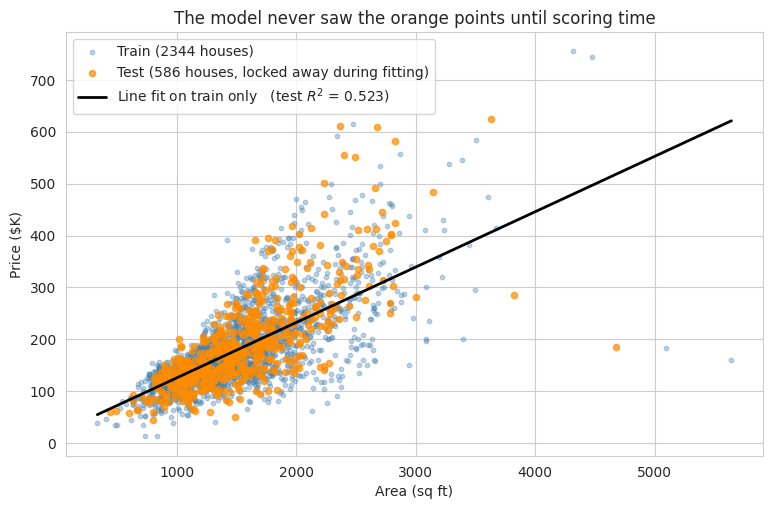

In [4]:
x_grid = np.linspace(X.min(), X.max(), 200).reshape(-1, 1)

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.scatter(X_train, y_train, s=10, alpha=0.35, color='steelblue',
           label=f'Train ({len(y_train)} houses)')
ax.scatter(X_test, y_test, s=20, alpha=0.7, color='darkorange',
           label=f'Test ({len(y_test)} houses, locked away during fitting)')
ax.plot(x_grid, model.predict(x_grid), color='black', linewidth=2,
        label=f'Line fit on train only   (test $R^2$ = {test_score:.3f})')
ax.set_xlabel('Area (sq ft)')
ax.set_ylabel('Price ($K)')
ax.set_title('The model never saw the orange points until scoring time')
ax.legend()
plt.show()

That's the entire mechanics of generalization testing. Three lines of sklearn:

```python
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model.fit(X_train, y_train)
print(model.score(X_test, y_test))    # the honest number
```

Every industrial ML pipeline in the world is built on that pattern.

### "But if it's the same in train and test, what's the big deal?"

Fair question. For a 2-parameter straight line through 2,930 houses, the cheating problem is almost invisible. Why bother?

Because the moment you add more variables, more curves, more flexibility — and you *will* — the cheating problem stops being invisible. It becomes the single biggest source of embarrassing machine-learning failures in the industry. Section 4 exists to show you what that looks like, so you never forget why we bothered.

---

## Section 4: Making Overfitting Visible

Let's construct a situation where the cheating problem is enormous, so you can see it happen in one plot.

**The setup.** We'll generate 30 synthetic data points from a known smooth function $y = \sin(x) + \text{noise}$. Then we'll fit four different models of increasing complexity — straight line, cubic, 10th-degree polynomial, 20th-degree polynomial — using only the training subset of those 30 points. We'll score each model on the training points it saw, and on fresh test points it didn't.

Polynomial regression (using $x, x^2, x^3, \ldots, x^d$ as extra features) is technically a peek ahead into multiple linear regression, but the core lesson is the same: *higher model complexity makes training error go down and can make test error go up.*


In [5]:
# Synthetic data: true function is y = sin(x), plus some noise.
def true_f(x):
    return np.sin(x)

n_train, n_test = 30, 200
x_train = rng.uniform(0, 2 * np.pi, size=n_train)
y_train_syn = true_f(x_train) + rng.normal(0, 0.3, size=n_train)

x_test = rng.uniform(0, 2 * np.pi, size=n_test)
y_test_syn = true_f(x_test) + rng.normal(0, 0.3, size=n_test)

# Reshape to 2D for sklearn.
Xtr = x_train.reshape(-1, 1)
Xte = x_test.reshape(-1, 1)

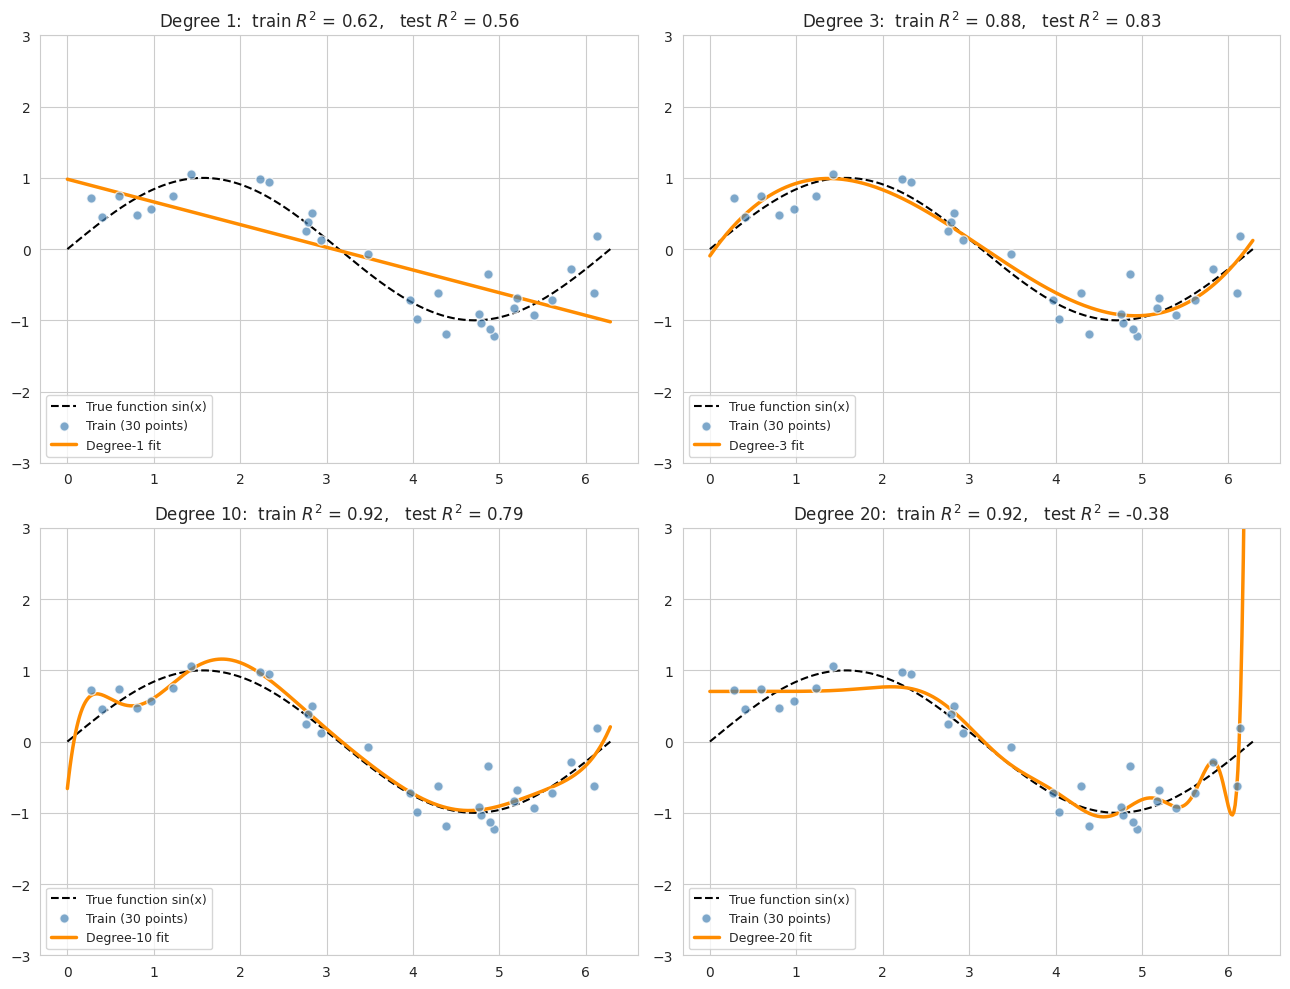

In [6]:
degrees_to_plot = [1, 3, 10, 20]
x_grid = np.linspace(0, 2 * np.pi, 400).reshape(-1, 1)

fig, axes = plt.subplots(2, 2, figsize=(13, 10))

for ax, d in zip(axes.flatten(), degrees_to_plot):
    # Polynomial regression of degree d: a one-liner with sklearn pipelines.
    poly_model = make_pipeline(PolynomialFeatures(degree=d), LinearRegression())
    poly_model.fit(Xtr, y_train_syn)

    tr_score = poly_model.score(Xtr, y_train_syn)
    te_score = poly_model.score(Xte, y_test_syn)

    ax.plot(x_grid, true_f(x_grid), color='black', linestyle='--', linewidth=1.5,
            label='True function sin(x)')
    ax.scatter(x_train, y_train_syn, s=45, color='steelblue', alpha=0.7,
               edgecolor='white', zorder=3, label=f'Train ({n_train} points)')
    ax.plot(x_grid, poly_model.predict(x_grid), color='darkorange', linewidth=2.5,
            label=f'Degree-{d} fit')

    ax.set_ylim(-3, 3)
    ax.set_title(f'Degree {d}:  train $R^2$ = {tr_score:.2f},   test $R^2$ = {te_score:.2f}')
    ax.legend(loc='lower left', fontsize=9)

plt.tight_layout()
plt.show()

Read those four panels left-to-right, top-to-bottom:

- **Degree 1 (a straight line).** Can't bend at all. Train $R^2$ is bad (a line through `sin(x)` is genuinely bad). Test $R^2$ is also bad. This is called **underfitting**: the model is too simple to capture the real structure.
- **Degree 3.** Now we have a nice smooth cubic. It hugs the true sine curve reasonably well. Train and test scores are both decent. This is the sweet spot.
- **Degree 10.** The orange curve starts to wriggle. You can see the model bending toward individual noisy training points. Train score has climbed (it's fitting the noise better), but test score is starting to suffer.
- **Degree 20.** The orange line is **insane**. It wiggles wildly between training points, shooting off near the edges of the data. It passes through almost every training point perfectly — train $R^2$ is near 1.0. But on *unseen* test data, the predictions are garbage. This is **overfitting** in its classic form: the model has memorized the training data (including all the noise) at the cost of predicting anything new.

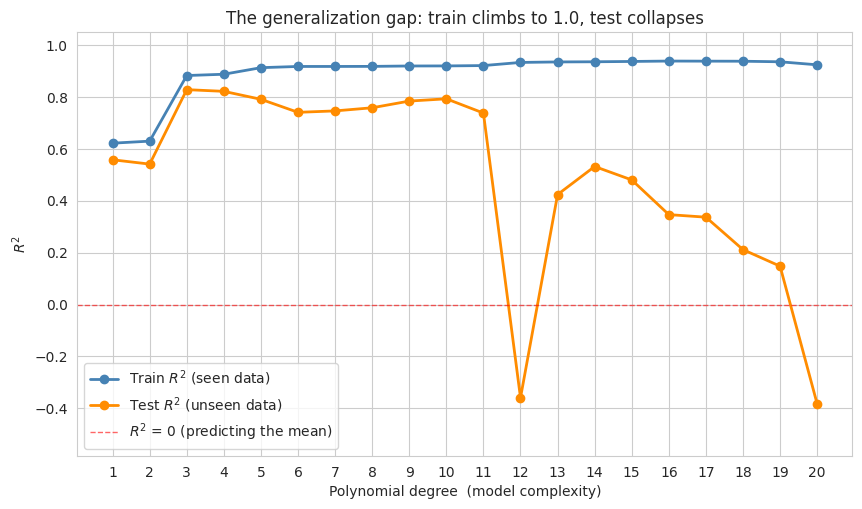

Best test R^2 occurs at degree 3 (test R^2 = 0.829)
Worst test R^2 at degree 20 (test R^2 = -0.383)


In [7]:
# Sweep polynomial degree from 1 to 20, record train and test R^2 at each step.
degrees = np.arange(1, 21)
train_scores, test_scores = [], []

for d in degrees:
    m = make_pipeline(PolynomialFeatures(degree=d), LinearRegression())
    m.fit(Xtr, y_train_syn)
    train_scores.append(m.score(Xtr, y_train_syn))
    test_scores.append(m.score(Xte, y_test_syn))

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.plot(degrees, train_scores, 'o-', color='steelblue', linewidth=2,
        label='Train $R^2$ (seen data)')
ax.plot(degrees, test_scores, 'o-', color='darkorange', linewidth=2,
        label='Test $R^2$ (unseen data)')
ax.axhline(0, color='red', linestyle='--', linewidth=1, alpha=0.6,
           label='$R^2$ = 0 (predicting the mean)')
ax.set_xlabel('Polynomial degree  (model complexity)')
ax.set_ylabel('$R^2$')
ax.set_xticks(degrees)
ax.set_ylim(min(test_scores) - 0.2, 1.05)
ax.set_title('The generalization gap: train climbs to 1.0, test collapses')
ax.legend()
plt.show()

print(f'Best test R^2 occurs at degree {degrees[int(np.argmax(test_scores))]} '
      f'(test R^2 = {max(test_scores):.3f})')
print(f'Worst test R^2 at degree {degrees[int(np.argmin(test_scores))]} '
      f'(test R^2 = {min(test_scores):.3f})')

**This plot is the entire reason modern machine learning exists.** Read it carefully.

- The **blue curve (train $R^2$)** only ever goes up. Adding more polynomial terms *always* lets the model fit the training points more snugly. If you care only about training performance, more complexity is always better.
- The **orange curve (test $R^2$)** rises sharply, peaks somewhere around degree 3–5 (the true function is smooth; we don't need 20-degree polynomials to describe sin(x)), and then **falls off a cliff**. Sometimes past some degree it goes *negative*.

### Wait — $R^2$ can be negative?

Yes. This is a teaching moment. On training data, $R^2$ is bounded between 0 (predicting the mean) and 1 (perfect fit), because OLS *always* beats or ties the mean-predictor on the data it was fit on. But on **unseen test data**, the fitted line is no longer optimal — it was chosen to fit a different set of points. A ridiculously overfit model can do *worse than just guessing the mean* on test data. When that happens, $R^2 < 0$.

> **A negative test $R^2$ is the clearest possible signal that you have overfit.** It means your fancy model is less useful than a ruler drawn at $\bar{y}$.

---

## Section 5: The Bias–Variance Tradeoff in One Page

Everything in Section 4 is an instance of a deeper principle called the **bias–variance tradeoff**. It's one of the two or three most important ideas in all of machine learning, and it shows up in every model you'll ever touch. Here's the three-line summary:

| Regime | Symptom | What's going on |
|---|---|---|
| **Underfitting** (high bias) | Train $R^2$ low, test $R^2$ low | Model is too simple to capture the real structure. Our degree-1 line through `sin(x)`. |
| **Goldilocks zone** | Train $R^2$ decent, test $R^2$ close to train | Model captures the real structure but ignores noise. Our degree-3 fit. |
| **Overfitting** (high variance) | Train $R^2$ near 1.0, test $R^2$ much lower (or negative) | Model is memorizing the training data, including noise. Our degree-20 wiggle-monster. |

The **train/test split** is the fundamental diagnostic tool for locating yourself on that spectrum. Without it, you literally cannot tell the difference between a good model and an overfit one — because on the training data they both look amazing.

### A one-sentence rule you can carry with you forever

> **The gap between train and test performance is your overfitting detector.** Small gap and both high? You're fine. Small gap and both low? Underfit — make the model more flexible. Large gap with train high and test low? Overfit — make the model simpler, or get more data.

---

## Putting It All Together (End of the SLR Arc)

This is the last notebook in the Simple Linear Regression module. Let's zoom out on the whole journey.

| Notebook | Question answered |
|---|---|
| 17_0_1 – 17_0_5 | What *is* a regression line, mathematically? (mean, TSS, covariance, correlation, RSS, $R^2$, closed-form slope) |
| 17_1_1 | How do the industry libraries fit it? (sklearn vs. statsmodels) |
| 17_1_2 | Is my slope real, or did I get lucky? (SE, p-values, CIs) |
| 17_1_3 | Are the assumptions behind those numbers holding? (LINE diagnostics) |
| 17_1_4 | Is a single bad row wrecking my fit? (leverage, outliers, Cook's Distance) |
| 17_1_5 | What if the shape is wrong? (log, reciprocal, polynomial transformations) |
| **17_1_6** | **Does my model work on data it has never seen?** (train/test split, overfitting) |

And the universal machine learning discipline you now know how to apply:

```python
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model.fit(X_train, y_train)
honest_r2 = model.score(X_test, y_test)
```

That three-line pattern is what separates hobby projects from real ML pipelines. Every time.

### Where We're Going Next

For SLR on Ames, the gap between train and test $R^2$ was essentially zero. So we lived through all of Section 4's overfitting horrors to prove a point about a failure mode we never actually hit.

But the moment you start using **more than one predictor** — area *and* number of bedrooms *and* year built *and* neighborhood *and* lot size *and* 40 other features — the overfitting problem comes right to your doorstep. Models with dozens or hundreds of parameters can memorize training data with alarming ease. A train/test split alone is no longer enough; you need **cross-validation**, which uses multiple splits to get a more reliable estimate of test performance, and **regularization**, which punishes the model for being too flexible.

That is what Module 18 is about: **Multiple Linear Regression and Cross-Validation**. Every single tool you learned in Module 17 — OLS, assumptions, influence, transformations, train/test splits — generalizes directly to many predictors. The math stays the same. The risks get bigger. The tools get sharper.

See you in Module 18.